In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, accuracy_score, f1_score
)


In [4]:
PASS_THRESHOLD = 65   # agreed in Phase 1 analysis
AT_RISK_PROB   = 0.70 # failure probability threshold

In [5]:
# 2. Load the Processed Data
train_df = pd.read_csv('train_processed.csv')
test_df = pd.read_csv('test_processed.csv')

In [6]:
train_df.head()

,Motivation_Level,Peer_Influence,Access_to_Resources,Parental_Involvement,Gender_Male,Extracurricular_Activities_Yes,Learning_Disabilities_Yes,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Stress_Proxy,Target
0,0.0,1.0,2.0,1.0,1.0,1.0,0.0,14.0,89.0,6.0,94.0,0.0,2.0,0.6939,1
1,0.0,2.0,0.0,1.0,0.0,1.0,0.0,22.0,81.0,7.0,80.0,1.0,3.0,0.6000,1
2,0.0,2.0,2.0,1.0,1.0,0.0,0.0,28.0,94.0,7.0,60.0,1.0,3.0,0.5545,1
3,2.0,0.0,2.0,1.0,0.0,0.0,0.0,11.0,67.0,8.0,52.0,3.0,3.0,0.3167,0
4,1.0,0.0,1.0,2.0,1.0,1.0,0.0,22.0,71.0,8.0,63.0,2.0,2.0,0.4000,1


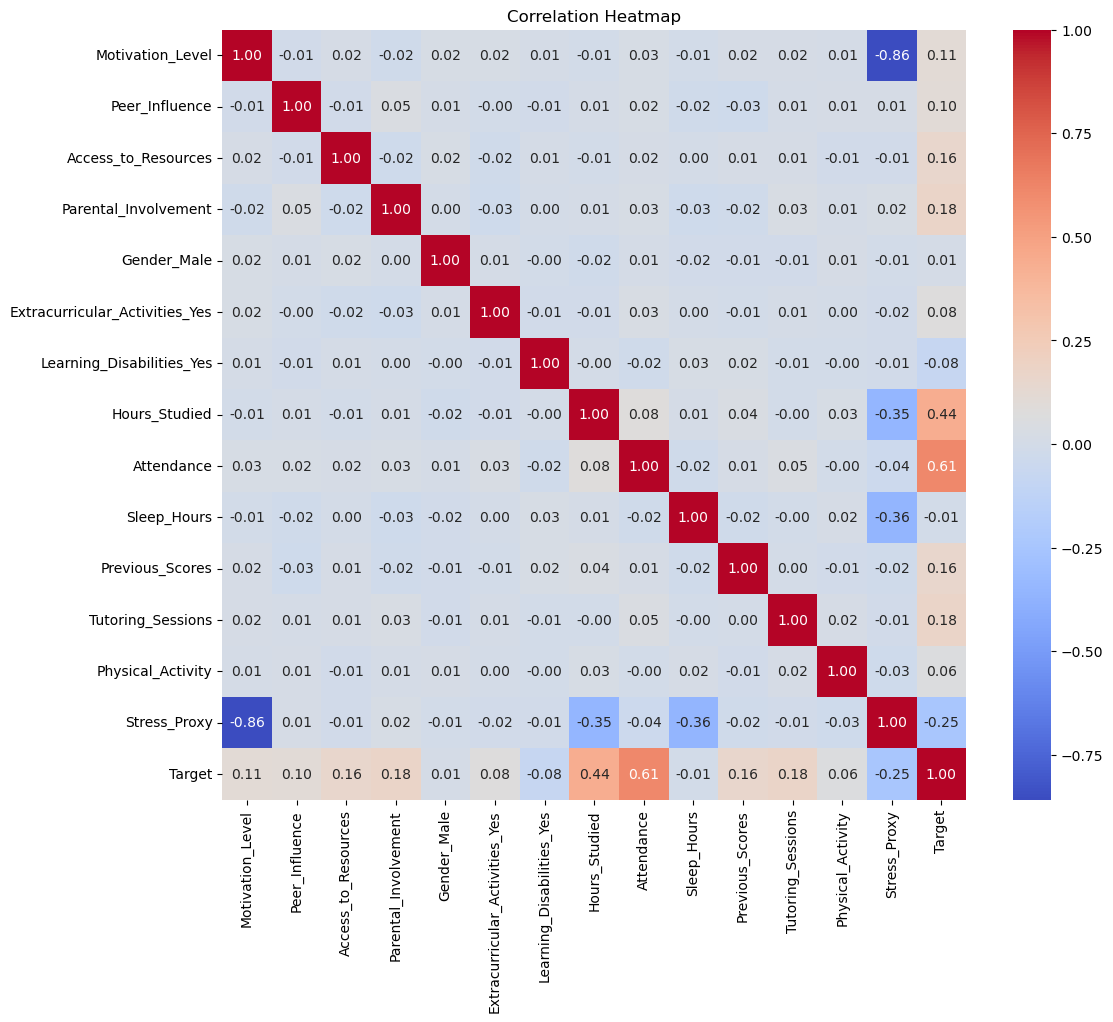

In [13]:
numeric_df = train_df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

In [11]:
# 3. Split & Scale

X_train = train_df.drop(columns=['Target'])
y_train = train_df['Target']

X_test = test_df.drop(columns=['Target'])
y_test = test_df['Target']

# 3. Scaling 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [25]:
joblib.dump(X_test_scaled, 'X_test_scaled.pkl')

['X_test_scaled.pkl']

In [17]:
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [21]:
# ─────────────────────────────────────────────
# 4. Train Four Models
# ─────────────────────────────────────────────
models = {
    'Logistic Regression':    LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':          DecisionTreeClassifier(max_depth=6, random_state=42),
    'Random Forest':          RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1),
    'Gradient Boosting':      GradientBoostingClassifier(n_estimators=200, max_depth=5, learning_rate=0.05, random_state=42),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

for name, model in models.items():
    Xtr = X_train_scaled if name == 'Logistic Regression' else X_train
    Xte = X_test_scaled  if name == 'Logistic Regression' else X_test

    model.fit(Xtr, y_train)
    preds  = model.predict(Xte)
    probas = model.predict_proba(Xte)[:, 1]

    cv_scores = cross_val_score(model, Xtr, y_train, cv=cv, scoring='accuracy')

    results[name] = {
        'model':    model,
        'preds':    preds,
        'probas':   probas,
        'acc':      accuracy_score(y_test, preds),
        'f1':       f1_score(y_test, preds),
        'auc':      roc_auc_score(y_test, probas),
        'cv_mean':  cv_scores.mean(),
        'cv_std':   cv_scores.std(),
        'report':   classification_report(y_test, preds, target_names=['Fail (0)', 'Pass (1)']),
        'cm':       confusion_matrix(y_test, preds),
        'Xte':      Xte,
    }


In [22]:
# ─────────────────────────────────────────────
# 5. Print Console Summary
# ─────────────────────────────────────────────
print("=" * 65)
print(f"{'MODEL COMPARISON':^65}")
print("=" * 65)
print(f"{'Model':<25} {'Accuracy':>9} {'F1':>8} {'ROC-AUC':>9} {'CV Mean±Std':>16}")
print("-" * 65)
for name, r in results.items():
    print(f"{name:<25} {r['acc']:>9.4f} {r['f1']:>8.4f} {r['auc']:>9.4f}  {r['cv_mean']:.4f}±{r['cv_std']:.4f}")
print("=" * 65)

best_name = max(results, key=lambda n: results[n]['auc'])
print(f"\n★  Best model by ROC-AUC: {best_name}")
print("\nDetailed Classification Report — Best Model:")
print(results[best_name]['report'])

                        MODEL COMPARISON                         
Model                      Accuracy       F1   ROC-AUC      CV Mean±Std
-----------------------------------------------------------------
Logistic Regression          0.9251   0.9513    0.9805  0.9441±0.0049
Decision Tree                0.8540   0.9039    0.8878  0.8877±0.0063
Random Forest                0.9047   0.9401    0.9596  0.9514±0.0043
Gradient Boosting            0.9130   0.9449    0.9696  0.9568±0.0044

★  Best model by ROC-AUC: Logistic Regression

Detailed Classification Report — Best Model:
              precision    recall  f1-score   support

    Fail (0)       0.80      0.88      0.84       291
    Pass (1)       0.97      0.94      0.95      1031

    accuracy                           0.93      1322
   macro avg       0.88      0.91      0.89      1322
weighted avg       0.93      0.93      0.93      1322




✅ Dashboard saved to ml_exam_classification.png


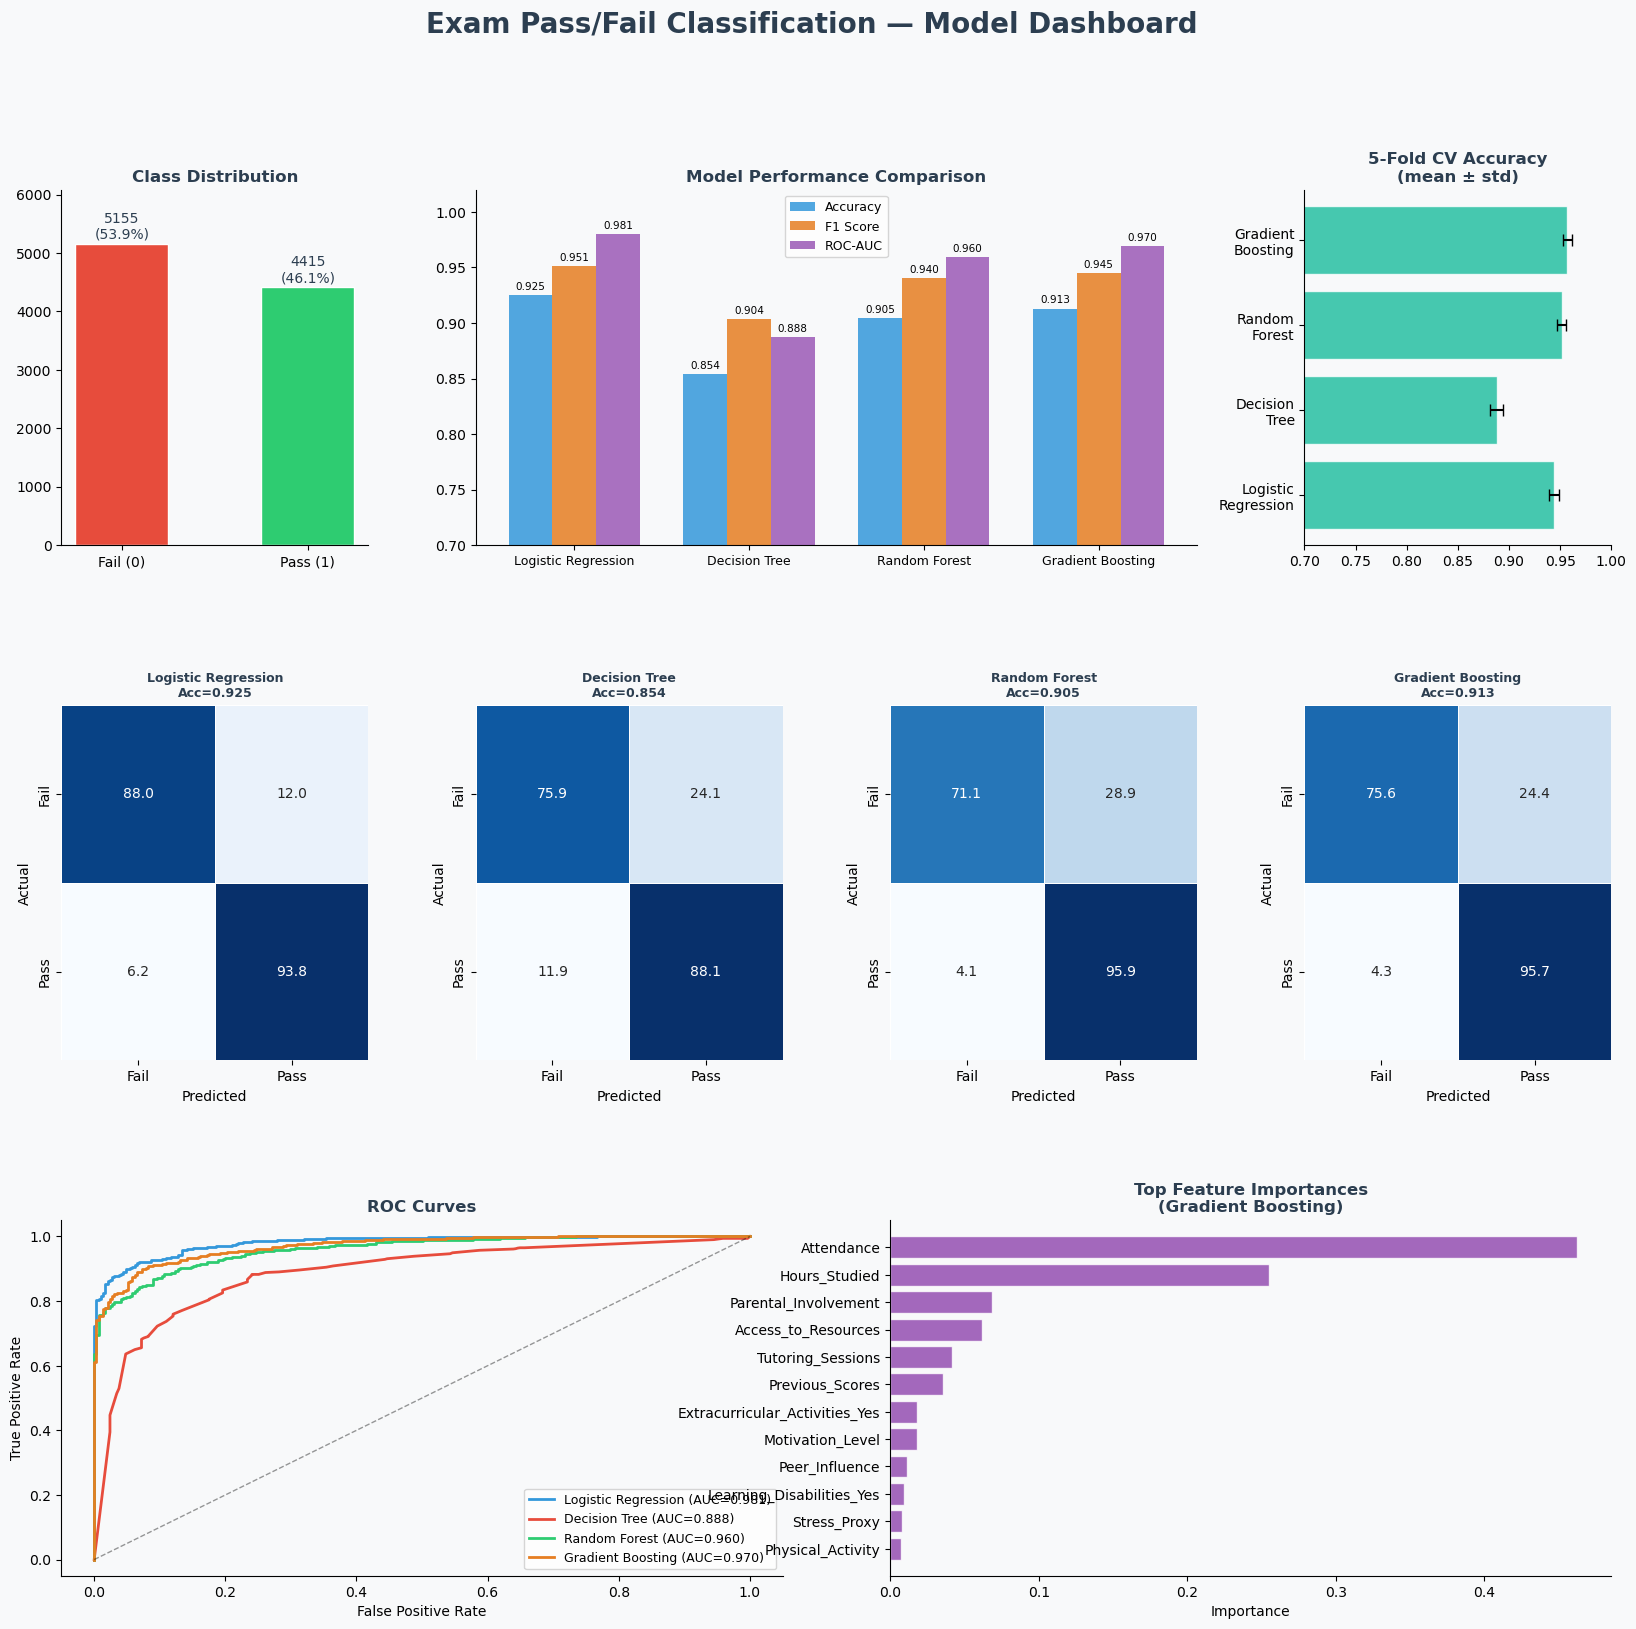

In [17]:
# ─────────────────────────────────────────────
# 6. Plot Dashboard
# ─────────────────────────────────────────────
y = pd.concat([y_train, y_test])
X = pd.concat([X_train, X_test])

PALETTE = {'Pass (1)': '#2ecc71', 'Fail (0)': '#e74c3c'}
BG      = '#f8f9fa'
ACCENT  = '#2c3e50'

fig = plt.figure(figsize=(20, 18), facecolor=BG)
fig.suptitle('Exam Pass/Fail Classification — Model Dashboard', fontsize=20,
             fontweight='bold', color=ACCENT, y=0.98)

gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.45, wspace=0.35)

# ── 6a. Target Distribution ──────────────────
ax0 = fig.add_subplot(gs[0, 0])
counts = y.value_counts()
bars = ax0.bar(['Fail (0)', 'Pass (1)'], counts.values,
               color=[PALETTE['Fail (0)'], PALETTE['Pass (1)']], edgecolor='white', width=0.5)
for bar, val in zip(bars, counts.values):
    ax0.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 40,
             f'{val}\n({val/len(y)*100:.1f}%)', ha='center', va='bottom', fontsize=10, color=ACCENT)
ax0.set_title('Class Distribution', fontweight='bold', color=ACCENT)
ax0.set_facecolor(BG); ax0.spines[['top','right']].set_visible(False)
ax0.set_ylim(0, max(counts.values)*1.18)


# ── 6b. Model Comparison Bar (Accuracy / F1 / AUC) ──
ax1 = fig.add_subplot(gs[0, 1:3])
metrics_df = pd.DataFrame({
    'Accuracy': [r['acc'] for r in results.values()],
    'F1 Score': [r['f1']  for r in results.values()],
    'ROC-AUC':  [r['auc'] for r in results.values()],
}, index=list(results.keys()))

x = np.arange(len(metrics_df))
w = 0.25
colors_m = ['#3498db', '#e67e22', '#9b59b6']
for i, (col, color) in enumerate(zip(metrics_df.columns, colors_m)):
    bars2 = ax1.bar(x + i*w, metrics_df[col], w, label=col, color=color, alpha=0.85)
    for bar in bars2:
        ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
                 f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7.5)

ax1.set_xticks(x + w); ax1.set_xticklabels(metrics_df.index, fontsize=9)
ax1.set_ylim(0.70, 1.02); ax1.set_title('Model Performance Comparison', fontweight='bold', color=ACCENT)
ax1.legend(fontsize=9); ax1.set_facecolor(BG); ax1.spines[['top','right']].set_visible(False)

# ── 6c. CV Score Comparison ──────────────────
ax_cv = fig.add_subplot(gs[0, 3])
cv_means = [r['cv_mean'] for r in results.values()]
cv_stds  = [r['cv_std']  for r in results.values()]
short_names = [n.replace(' ', '\n') for n in results.keys()]
bars_cv = ax_cv.barh(short_names, cv_means, xerr=cv_stds, color='#1abc9c',
                     alpha=0.8, capsize=4, edgecolor='white')
ax_cv.set_xlim(0.7, 1.0)
ax_cv.set_title('5-Fold CV Accuracy\n(mean ± std)', fontweight='bold', color=ACCENT)
ax_cv.set_facecolor(BG); ax_cv.spines[['top','right']].set_visible(False)

# ── 6d. Confusion Matrices (all 4 models) ────
for idx, (name, r) in enumerate(results.items()):
    ax = fig.add_subplot(gs[1, idx])
    cm_pct = r['cm'].astype(float) / r['cm'].sum(axis=1, keepdims=True) * 100
    sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
                xticklabels=['Fail','Pass'], yticklabels=['Fail','Pass'],
                ax=ax, cbar=False, linewidths=0.5)
    ax.set_title(f'{name}\nAcc={r["acc"]:.3f}', fontweight='bold', color=ACCENT, fontsize=9)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')

# ── 6e. ROC Curves ───────────────────────────
ax_roc = fig.add_subplot(gs[2, 0:2])
roc_colors = ['#3498db', '#e74c3c', '#2ecc71', '#e67e22']
for (name, r), color in zip(results.items(), roc_colors):
    fpr, tpr, _ = roc_curve(y_test, r['probas'])
    ax_roc.plot(fpr, tpr, color=color, lw=2,
                label=f'{name} (AUC={r["auc"]:.3f})')
ax_roc.plot([0,1],[0,1],'k--', lw=1, alpha=0.4)
ax_roc.set_xlabel('False Positive Rate'); ax_roc.set_ylabel('True Positive Rate')
ax_roc.set_title('ROC Curves', fontweight='bold', color=ACCENT)
ax_roc.legend(fontsize=9); ax_roc.set_facecolor(BG)
ax_roc.spines[['top','right']].set_visible(False)

# ── 6f. Feature Importance (best tree-based model) ─
best_tree = max(
    {n: r for n, r in results.items() if n != 'Logistic Regression'},
    key=lambda n: results[n]['auc']
)
importances = results[best_tree]['model'].feature_importances_
feat_df = pd.Series(importances, index=X.columns).sort_values(ascending=True).tail(12)

ax_fi = fig.add_subplot(gs[2, 2:4])
bars_fi = ax_fi.barh(feat_df.index, feat_df.values, color='#8e44ad', alpha=0.8, edgecolor='white')
ax_fi.set_title(f'Top Feature Importances\n({best_tree})', fontweight='bold', color=ACCENT)
ax_fi.set_facecolor(BG); ax_fi.spines[['top','right']].set_visible(False)
ax_fi.set_xlabel('Importance')

import os
os.makedirs('/mnt/user-data/outputs', exist_ok=True)

plt.savefig('/mnt/user-data/outputs/ml_exam_classification.png', dpi=150,
            bbox_inches='tight', facecolor=BG)
print("\n✅ Dashboard saved to ml_exam_classification.png")

In [18]:
train_df.head()

,Motivation_Level,Peer_Influence,Access_to_Resources,Parental_Involvement,Gender_Male,Extracurricular_Activities_Yes,Learning_Disabilities_Yes,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Stress_Proxy,Target
0,0.0,1.0,2.0,1.0,1.0,1.0,0.0,14.0,89.0,6.0,94.0,0.0,2.0,0.6939,1
1,0.0,2.0,0.0,1.0,0.0,1.0,0.0,22.0,81.0,7.0,80.0,1.0,3.0,0.6000,1
2,0.0,2.0,2.0,1.0,1.0,0.0,0.0,28.0,94.0,7.0,60.0,1.0,3.0,0.5545,1
3,2.0,0.0,2.0,1.0,0.0,0.0,0.0,11.0,67.0,8.0,52.0,3.0,3.0,0.3167,0
4,1.0,0.0,1.0,2.0,1.0,1.0,0.0,22.0,71.0,8.0,63.0,2.0,2.0,0.4000,1


In [19]:
# 1. استخراج القيم القصوى (عشان الـ Stress_Proxy يفضل صح)
max_sleep = train_df['Sleep_Hours'].max()
max_hours = train_df['Hours_Studied'].max()

# 2. تجهيز بيانات الطلاب الجدد (بكل الأعمدة اللي الموديل بيطلبها)
test_students_raw = pd.DataFrame({
    'Hours_Studied': [18, 5, 10],
    'Attendance': [95, 60, 80],
    'Sleep_Hours': [8, 5, 7],
    'Previous_Scores': [90, 50, 70],           # عمود ناقص ضفناه
    'Tutoring_Sessions': [2, 0, 1],            # عمود ناقص ضفناه
    'Physical_Activity': [3, 1, 2],            # عمود ناقص ضفناه
    'Motivation_Level': ['High', 'Low', 'Medium'],
    'Parental_Involvement': ['High', 'Low', 'Medium'], # عمود ناقص ضفناه
    'Access_to_Resources': ['High', 'Low', 'Medium'],
    'Peer_Influence': ['Positive', 'Negative', 'Neutral'],
    'Extracurricular_Activities_Yes': [1, 0, 1], # الموديل متوقع الاسم كدة بعد الـ Encoding
    'Learning_Disabilities_Yes': [0, 0, 0],      # الموديل متوقع الاسم كدة
    'Gender_Male': [0, 1, 0]                     # الموديل متوقع الاسم كدة
})

# 3. تحويل القيم النصية لأرقام للأعمدة اللي لسه نصوص
mot_map = {'Low': 0, 'Medium': 1, 'High': 2}
test_students = test_students_raw.copy()
test_students['Motivation_Level'] = test_students['Motivation_Level'].map(mot_map)
test_students['Parental_Involvement'] = test_students['Parental_Involvement'].map(mot_map)
test_students['Access_to_Resources'] = test_students['Access_to_Resources'].map(mot_map)
test_students['Peer_Influence'] = test_students['Peer_Influence'].map({'Negative': 0, 'Neutral': 1, 'Positive': 2})

# 4. حساب الـ Stress_Proxy (معادلتك)
sleep_norm = test_students['Sleep_Hours'] / max_sleep
mot_norm   = test_students['Motivation_Level'] / 2
hours_norm = test_students['Hours_Studied'] / max_hours

test_students['Stress_Proxy'] = ((1 - sleep_norm) + (1 - mot_norm) + (1 - hours_norm)) / 3
test_students['Stress_Proxy'] = test_students['Stress_Proxy'].round(4)

# 5. التوقع (الآن الترتيب هيتظبط أوتوماتيكياً)
# الكود ده هيجيب الأعمدة اللي الموديل متعود عليها بالظبط
final_cols = X_train.columns.tolist()
test_students = test_students.reindex(columns=final_cols, fill_value=0) 

test_students_scaled = scaler.transform(test_students)
final_preds = results['Logistic Regression']['model'].predict(test_students_scaled)
# الحصول على الاحتمالات (Probability) لكل طالب
# هذه الدالة تعطي قائمة تحتوي على [احتمال الفشل، احتمال النجاح]
final_probs = results['Logistic Regression']['model'].predict_proba(test_students_scaled)

# 6. عرض النتيجة مع احتمالية النجاح والفشل
print("=" * 50)
print(f"{'Student':<12} | {'Status':<8} | {'Pass Prob %':<12} | {'Fail Prob %':<12}")
print("-" * 50)

for i, name in enumerate(['الطالب A', 'الطالب B', 'الطالب C']):
    status = 'PASS' if final_preds[i] == 1 else 'FAIL'
    pass_pct = final_probs[i][1] * 100  # احتمالية النجاح
    fail_pct = final_probs[i][0] * 100  # احتمالية الفشل
    
    print(f"{name:<12} | {status:<8} | {pass_pct:>10.1f}% | {fail_pct:>10.1f}%")
print("=" * 50)

Student      | Status   | Pass Prob %  | Fail Prob % 
--------------------------------------------------
الطالب A     | PASS     |      100.0% |        0.0%
الطالب B     | FAIL     |        0.0% |      100.0%
الطالب C     | FAIL     |        3.5% |       96.5%


In [20]:
import joblib

# تجميع كل شيء في قاموس (Dictionary) واحد
model_package = {
    'model': results['Logistic Regression']['model'],
    'scaler': scaler,
    'columns': X_train.columns.tolist(), # ترتيب الأعمدة
    'max_sleep': train_df['Sleep_Hours'].max(),
    'max_hours': train_df['Hours_Studied'].max()
}

# حفظ الملف
joblib.dump(model_package, 'student_model_package.pkl')
print("✅ تم حفظ ملف student_model_package.pkl بنجاح!")

✅ تم حفظ ملف student_model_package.pkl بنجاح!


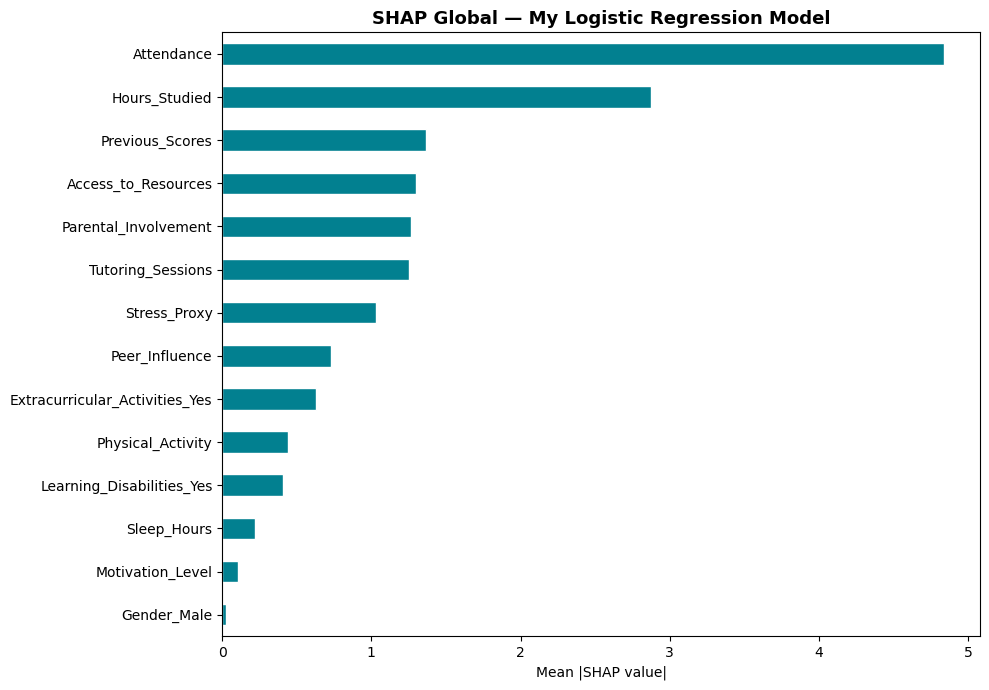

In [26]:

# 1. استخراج موديل الـ Logistic Regression من نتائج التدريب
# نصل إليه عن طريق المفتاح 'Logistic Regression' ثم 'model'
my_lr_model = results['Logistic Regression']['model']

# 2. استخراج بيانات الاختبار المقيّسة (Xte) التي تم تخزينها للموديل الخاص بكِ
Xte_scaled = results['Logistic Regression']['Xte']

# 3. استخدام LinearExplainer لأنه الأنسب لـ Logistic Regression
# نمرر الموديل وبيانات التدريب المقيّسة كمرجع (Background)
explainer = shap.LinearExplainer(my_lr_model, X_train_scaled) 

# 4. حساب قيم SHAP لعينة من بيانات الاختبار (مثلاً أول 300 طالب)
X_sample = Xte_scaled[:300] 
shap_values = explainer.shap_values(X_sample)

# 5. حساب الأهمية المتوسطة ورسمها بنفس استايل زميلك
mean_shap = abs(shap_values).mean(axis=0)
shap_importance = pd.Series(mean_shap, index=X_train.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
shap_importance.plot(kind="barh", ax=ax, color="#028090", edgecolor="white")
ax.set_title("SHAP Global — My Logistic Regression Model", fontsize=13, fontweight="bold")
ax.set_xlabel("Mean |SHAP value|")
plt.tight_layout()
plt.show()

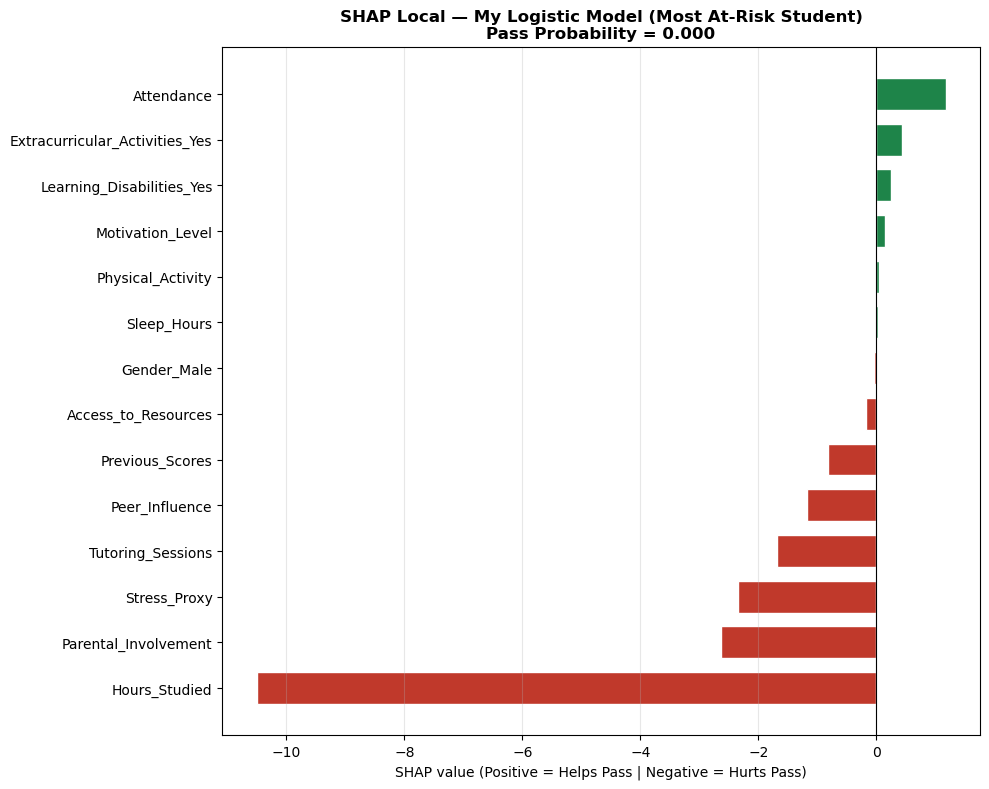

Student Diagnosis:
  The main reason for risk is: Hours_Studied (Value: -10.5050)


In [30]:
# STEP 14 (Modified) — SHAP Local Explanation for Logistic Regression

# 1. اختيار الطالب الأكثر عرضة للخطر (أقل احتمالية نجاح)
# نستخدم الاحتمالات المخزنة في نتائج الموديل الخاص بكِ
proba_sample = results['Logistic Regression']['probas'][:300]
at_risk_idx  = proba_sample.argmin() 
pass_prob    = proba_sample[at_risk_idx]

# 2. استخراج قيم SHAP لهذا الطالب تحديداً
# ملاحظة: shap_values تم حسابها في الخطوة السابقة (Global)
student_shap = pd.Series(shap_values[at_risk_idx], index=X_train.columns).sort_values()

# 3. تحديد الألوان: أخضر للقيم التي تدفع للنجاح | أحمر للقيم التي تدفع للفشل
bar_colors = ["#1E8449" if v > 0 else "#C0392B" for v in student_shap.values]

# 4. رسم المخطط
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(student_shap.index, student_shap.values, color=bar_colors, edgecolor="white", height=0.7)
ax.axvline(0, color="black", lw=0.8)

ax.set_title(
    f"SHAP Local — My Logistic Model (Most At-Risk Student)\n"
    f"Pass Probability = {pass_prob:.3f}", 
    fontsize=12, fontweight="bold"
)
ax.set_xlabel("SHAP value (Positive = Helps Pass | Negative = Hurts Pass)")
ax.grid(True, alpha=0.3, axis="x")

plt.tight_layout()
# حفظ الصورة لاستخدامها في التقرير أو الـ Dashboard
plt.savefig("my_shap_local.png", bbox_inches="tight", dpi=150)
plt.show()

# 5. طباعة التشخيص السريع (تمهيداً لـ Phase 3)
worst_feature = student_shap.idxmin()
print(f"Student Diagnosis:")
print(f"  The main reason for risk is: {worst_feature} (Value: {student_shap.min():.4f})")

In [32]:
#save shap explainer
joblib.dump(explainer, "my_lr_explainer.pkl")


['my_lr_explainer.pkl']

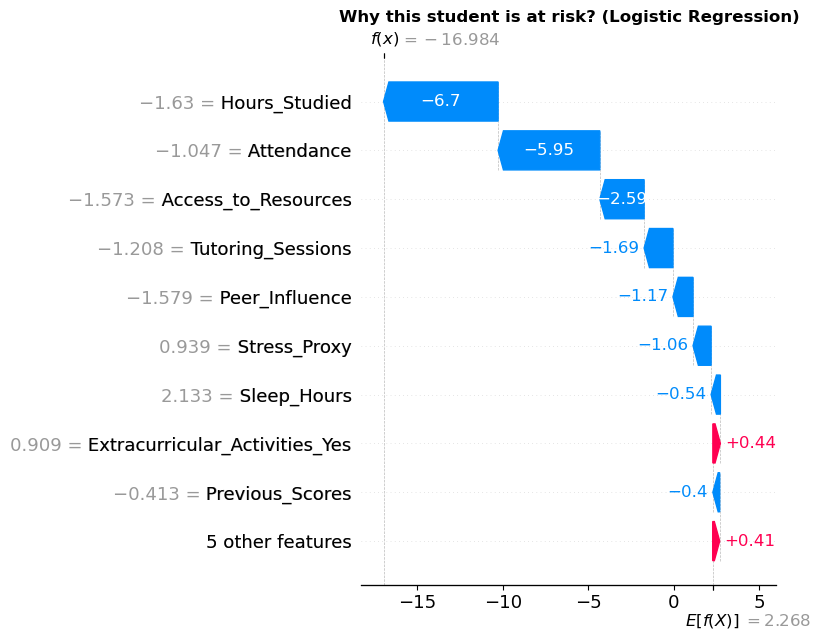

In [34]:
# 1. حساب الـ SHAP لموديلك (Logistic Regression)
explainer = shap.LinearExplainer(results['Logistic Regression']['model'], X_train_scaled)
shap_values = explainer.shap_values(X_test_scaled)

# 2. اختيار الطالب الأكثر عرضة للفشل
at_risk_idx = results['Logistic Regression']['probas'].argmin()

# 3. إنشاء كائن التفسير (Explanation Object) ليعمل مع رسمة الـ Waterfall
# نستخدم [at_risk_idx] للحصول على بيانات هذا الطالب تحديداً
exp = shap.Explanation(
    values=shap_values[at_risk_idx], 
    base_values=explainer.expected_value, 
    data=X_test_scaled[at_risk_idx], 
    feature_names=X_train.columns
)

# 4. الرسم بشكل Waterfall (الأرقى والأفضل للعرض)
plt.figure(figsize=(10, 6))
shap.plots.waterfall(exp, show=False)
plt.title(f"Why this student is at risk? (Logistic Regression)", fontweight='bold')
plt.tight_layout()
plt.show()